## Plan

This jupyter notebook breaks down the flow of using OCHRE for building 
predictive control

Functions for the rest of the script:

In [116]:
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cvxpy as cp
import numpy as np
from numpy.ma.core import ones_like

In [117]:
def attach_epw_to_df(df, epw_path,
                     keep_cols=("Dry Bulb (C)",
                                "Relative Humidity (%)",
                                "Global Horizontal Radiation (Wh/m^2)",
                                "Wind Speed (m/s)"),
                     out_names=("Temperature - Outdoor (C) [EPW]",
                                "Relative Humidity - Outdoor (%) [EPW]",
                                "Global Horizontal Irradiance (W/m^2) [EPW]",  # EPW is Wh/m² (hourly avg)
                                "Wind Speed - Outdoor (m/s) [EPW]")):
    # --- read EPW ---
    cols = [
        "Year","Month","Day","Hour","Minute","Flags",
        "Dry Bulb (C)","Dew Point (C)","Relative Humidity (%)","Atmos Pressure (Pa)",
        "Extraterrestrial Horizontal Radiation (Wh/m^2)",
        "Extraterrestrial Direct Normal Radiation (Wh/m^2)",
        "Horizontal IR Intensity (Wh/m^2)",
        "Global Horizontal Radiation (Wh/m^2)",
        "Direct Normal Radiation (Wh/m^2)",
        "Diffuse Horizontal Radiation (Wh/m^2)",
        "Global Horizontal Illuminance (lux)",
        "Direct Normal Illuminance (lux)",
        "Diffuse Horizontal Illuminance (lux)",
        "Zenith Luminance (Cd/m^2)",
        "Wind Direction (deg)","Wind Speed (m/s)","Total Sky Cover (tenths)",
        "Opaque Sky Cover (tenths)","Visibility (km)","Ceiling Height (m)",
        "Present Weather Observation","Present Weather Codes",
        "Precipitable Water (mm)","Aerosol Optical Depth (thousandths)",
        "Snow Depth (cm)","Days Since Last Snowfall",
        "Albedo","Liquid Precipitation Depth (mm)","Liquid Precipitation Quantity (hr)"
    ]
    epw = pd.read_csv(epw_path, skiprows=8, header=None, names=cols)

    # --- Build timestamp ignoring EPW 'Year' ---
    # EPW Hour = 1..24 marks END of hour → convert to start of hour
    h = epw["Hour"].to_numpy()
    carry = (h == 24).astype(int)
    hour0 = (h % 24)

    # choose a single year: the sim's year
    sim_year = int(df.index[0].year)

    dt = pd.to_datetime({
        "year": sim_year,                            # force a single year
        "month": epw["Month"],
        "day": epw["Day"],
        "hour": hour0,
        # EPW minute is usually 0 for hourly TMY; include if present
        "minute": epw["Minute"] if "Minute" in epw else 0
    })
    # shift hour=24 rows to next day (now within the same sim_year)
    dt = dt + pd.to_timedelta(carry, unit="D")

    wx = epw.set_index(dt)[list(keep_cols)].copy()
    wx.columns = list(out_names)

    # RH sanity
    if "Relative Humidity - Outdoor (%) [EPW]" in wx:
        wx["Relative Humidity - Outdoor (%) [EPW]"] = wx["Relative Humidity - Outdoor (%) [EPW]"].clip(0, 100)

    # Align to sim timeline; hourly → sub-hourly via forward-fill
    # If df has irregular start (e.g., not exactly at :00), also bfill edges.
    wx_aligned = wx.reindex(df.index, method="ffill").bfill()

    # Join
    out = df.join(wx_aligned, how="left")
    return out




In [118]:
def comfort_schedule(start_time, n_horizon, time_step):
    """
    Returns time-varying T_min and T_max arrays for the next n_horizon hours.
    
    - 19–23 °C between 6 PM (18:00) and 9 AM (09:00)
    - 16–27 °C otherwise
    """
    
    freq_string = f'{time_step}min'
    
    # Hourly horizon
    hours = pd.date_range(start=start_time, periods=n_horizon, freq=freq_string)

    T_min = np.zeros(n_horizon)
    T_max = np.zeros(n_horizon)

    for i, h in enumerate(hours.hour):
        if h >= 18 or h < 9:     # 6 PM–9 AM
            T_min[i] = 19.0
            T_max[i] = 23.0
        else:                    # 9 AM–6 PM
            T_min[i] = 16.0
            T_max[i] = 27.0

    return T_min, T_max

In [119]:
def weather_predict(epw_path, t_now, n_horizon):
    cols = [
        "Year","Month","Day","Hour","Minute","Flags",
        "Dry Bulb (C)","Dew Point (C)","Relative Humidity (%)","Atmos Pressure (Pa)",
        "Extraterrestrial Horizontal Radiation (Wh/m^2)",
        "Extraterrestrial Direct Normal Radiation (Wh/m^2)",
        "Horizontal IR Intensity (Wh/m^2)",
        "Global Horizontal Radiation (Wh/m^2)",
        "Direct Normal Radiation (Wh/m^2)",
        "Diffuse Horizontal Radiation (Wh/m^2)",
        "Global Horizontal Illuminance (lux)",
        "Direct Normal Illuminance (lux)",
        "Diffuse Horizontal Illuminance (lux)",
        "Zenith Luminance (Cd/m^2)",
        "Wind Direction (deg)","Wind Speed (m/s)","Total Sky Cover (tenths)",
        "Opaque Sky Cover (tenths)","Visibility (km)","Ceiling Height (m)",
        "Present Weather Observation","Present Weather Codes",
        "Precipitable Water (mm)","Aerosol Optical Depth (thousandths)",
        "Snow Depth (cm)","Days Since Last Snowfall",
        "Albedo","Liquid Precipitation Depth (mm)","Liquid Precipitation Quantity (hr)"
    ]
    epw = pd.read_csv(epw_path, skiprows=8, header=None, names=cols)

    # Build a datetime index for the EPW (assumes typical EPW hour stamps 1..24)
    # EPW "Hour" is 1..24 -> convert to 0..23
    epw["Hour0"] = epw["Hour"] - 1
    # Use a dummy year (EPW year field is unreliable). Align by Month/Day/Hour only.
    dt_index = pd.to_datetime(dict(
        year=2001, month=epw["Month"], day=epw["Day"], hour=epw["Hour0"], minute=0
    ))
    epw.index = dt_index

    # Build the forecast index (hourly)
    idx = pd.date_range(t_now.floor('h'), periods=n_horizon, freq='h')  # 
    # include current hour
    # Map by (month, day, hour); for a real forecast you’d use an API—this is EPW “typical”.
    epw_key = list(zip(epw.index.month, epw.index.day, epw.index.hour))
    map_df = epw[["Dry Bulb (C)","Relative Humidity (%)","Wind Speed (m/s)", "Global Horizontal Radiation (Wh/m^2)"
                  ]].copy()
    map_df["m"] = epw.index.month; map_df["d"] = epw.index.day; map_df["h"] = epw.index.hour

    out = []
    for ts in idx:
        subset = map_df[(map_df["m"]==ts.month)&(map_df["d"]==ts.day)&(map_df["h"]==ts.hour)]
        if subset.empty:
            subset = map_df[(map_df["m"]==ts.month)&(map_df["h"]==ts.hour)]
        row = subset.iloc[0]
        out.append([row["Dry Bulb (C)"], row["Relative Humidity (%)"], 
                    row["Wind Speed (m/s)"], row["Global Horizontal Radiation (Wh/m^2)"]])

    df = pd.DataFrame(out, index=idx, columns=["Dry Bulb (C)","Relative "
                                                              "Humidity (%)",
                                               "Wind Speed (m/s)", "Global Horizontal Radiation (Wh/m^2)"])
    return df

In [120]:
def forecast_COP_vector(T_amb_vec, hvac):
    """
    Returns eta_hat = COP forecast for each hour in the horizon.
    Uses highest 'speed' biquad in hvac.biquad_params (or speed=1 if only 1).
    """
    # pick a speed key; here: the max available (often "high" speed entry)
    speed_keys = sorted(hvac.biquad_params.keys())
    speed = speed_keys[-1]

    params = hvac.biquad_params[speed]
    eir_t  = params['eir_t']    # [a,b,c,d,e,f]
    cap_t  = params['cap_t']    # [a,b,c,d,e,f]

    Q_rated   = hvac.capacity_list[speed]  # W
    EIR_rated = hvac.eir_list[speed]
    # COP_rated = 1.0 / EIR_rated  # (not needed explicitly)

    Tin0 = 21.0  # fixed indoor reference for temp modifiers

    a,b,c,d,e,f = eir_t
    a_p = a + b*Tin0 + c*(Tin0**2)
    b_p = d + f*Tin0
    c_p = e

    ac,bc,cc,dc,ec,fc = cap_t
    aC = ac + bc*Tin0 + cc*(Tin0**2)
    bC = dc + fc*Tin0
    cC = ec

    T = np.asarray(T_amb_vec, dtype=float)
    cap_mod = aC + bC*T + cC*(T**2)
    eir_mod = a_p + b_p*T + c_p*(T**2)

    COP = cap_mod / (EIR_rated * eir_mod)
    # You may want to clip COP to reasonable bounds to avoid numerical issues
    return np.clip(COP, 1.2, 7.0)

In [121]:
def electricity_price(t_now, dt_mpc, N, rate_type):
    """
    Build an electricity price vector for an MPC horizon.

    Parameters
    ----------
    t_now : datetime.datetime
        Current simulation time (start of the MPC horizon).
    dt_mpc : float
        MPC time-step in minutes (e.g., 60 for 1 hour).
    N : int
        Prediction horizon length (number of MPC steps).
    rate_type : {"flat", "tou"}
        - "flat": constant 0.093 $/kWh
        - "tou":  0.21 $/kWh from 5–9 pm (17:00–21:00, 21:00 exclusive),
                 0.07 $/kWh otherwise.

    Returns
    -------
    c_elec : np.ndarray, shape (N,)
        Electricity price at each MPC step in $/kWh.
    """

    # Build the actual timestamps over the horizon
    times = [t_now + dt.timedelta(minutes=k * dt_mpc) for k in range(N)]
    #print(times)
    rate_type = rate_type.lower()

    if rate_type == "flat":
        #print("Flat")
        # Constant flat rate
        return np.full(N, 0.093)

    elif rate_type == "tou":
        #print("TOU")
        prices = []
        for t_i in times:
            #print(t_i)
            hour = t_i.hour
            # Peak from 5–9 pm: interpret as 17:00–21:00 (21:00 exclusive)
            if 17 <= hour < 21:
                prices.append(0.21)
            else:
                prices.append(0.07)
        return np.array(prices)

    else:
        raise ValueError(
            f"Unknown rate_type '{rate_type}'. Use 'flat' or 'tou'.")


In [122]:
def hankel_matrix(data,L):
    """
    Construct a block Hankel matrix of depth L from time-series data.

    Parameters
    ----------
    data : np.ndarray, shape (T, d)
        The time series (each row is a timestep, each column a variable).
    L : int
        The number of block rows (window length).

    Returns
    -------
    H : np.ndarray, shape (L*d, T - L + 1)
        The block Hankel matrix.
    d : the corresponding channels for the data 
    """
    data_new = np.atleast_2d(data)
    if data_new.shape[0] == 1:
        data = data_new.T
    
    T,d = data.shape
    cols = T-L+1
    H = np.zeros((L*d,cols))
    for i in range(L):
        H[i*d:(i+1)*d, :] = data[i:i+cols, :].T
    return H,d

In [123]:
def run_DeePC(U_p_tr,Y_p_tr,U_f_tr,Y_f_tr,T_out_hat, q_solar_hat, eta_hat,
              T_in_hist, T_out_hist, q_hp_hist, q_solar_hist, T_ini, N, 
              dt, T_min, T_max, T_pref,P_r, HP_deadband, P_max):
    
    X_1 = q_hp_hist
    X_2 = (T_out_hist - T_in_hist)
    X_3 = q_solar_hist
    X = np.column_stack((X_1, X_2, X_3))

    # Align with diff'ed output (one step shorter)
    X = X[:-1, :]

    # Output: dT_in/dt
    Y = np.diff(T_in_hist) / float(dt)
    Y_col = np.asarray(Y, dtype=float).reshape(-1, 1)

    L = int(T_ini + N)
    if X.shape[0] < L:
        raise ValueError(f"Not enough data for Hankel: have {X.shape[0]}, need at least {L}")

    # -----------------------------
    # 2) Hankel matrices & splits
    # -----------------------------
    U_H, m = hankel_matrix(X, L)      # m = number of inputs (here 3)
    Y_H, p = hankel_matrix(Y_col, L)  # p = number of outputs (here 1)

    U_p_new = U_H[:T_ini * m, :]
    Y_p_new = Y_H[:T_ini * p, :]
    U_f_new = U_H[T_ini * m:, :]
    Y_f_new = Y_H[T_ini * p:, :]
    
    '''
    print(L)
    print(len(Y_col))
    
    print("U_f_tr.shape:", U_f_tr.shape)
    print("U_f_new.shape:", U_f_new.shape)
    
    # If you're building from Hankels, also print:
    print("U_p_tr.shape:", U_p_tr.shape)
    print("U_p_new.shape:", U_p_new.shape)
    print("Y_f_tr.shape:", Y_f_tr.shape)
    print("Y_f_new.shape:", Y_f_new.shape)
    '''

    U_p = np.column_stack([U_p_tr, U_p_new])
    U_f = np.column_stack([U_f_tr, U_f_new])
    Y_p = np.column_stack([Y_p_tr, Y_p_new])
    Y_f = np.column_stack([Y_f_tr, Y_f_new])

    H = np.vstack([U_p, Y_p, U_f, Y_f])

    # Most recent column of new past data
    k_new = U_H.shape[1] - 1
    u_p = U_p_new[:, [k_new]]   # (T_ini*m, 1)
    y_p = Y_p_new[:, [k_new]]   # (T_ini*p, 1)

    # Preference indicator
    T_min_arr = np.asarray(T_min, dtype=float)
    pi = (T_min_arr == np.max(T_min_arr)).astype(float)

    n_g = H.shape[1]

    # -----------------------------
    # 3) Decision variables
    # -----------------------------
    T     = cp.Variable(N + 1)      # indoor temperature trajectory
    P_hp  = cp.Variable(N)          # HP electric power
    q     = cp.Variable(N)          # HP thermal input
    P_aux = cp.Variable(N)          # electric resistance
    P_tot = cp.Variable(N)          # total electric power
    g     = cp.Variable(n_g)        # DeePC weights
    u_f   = cp.Variable(m * N)      # stacked future inputs
    y_f   = cp.Variable(p * N)      # stacked future outputs (dT/dt)
    
    # -----------------------------
    # 4) Known predictions (length N)
    # -----------------------------
    T_out_hat    = np.asarray(T_out_hat, dtype=float).reshape(N)
    q_solar_hat  = np.asarray(q_solar_hat, dtype=float).reshape(N)
    eta_hat      = np.asarray(eta_hat, dtype=float).reshape(N)
    T_min        = np.asarray(T_min, dtype=float).reshape(N)
    T_max        = np.asarray(T_max, dtype=float).reshape(N)
    T_pref       = np.asarray(T_pref, dtype=float).reshape(N)
    pi           = np.asarray(pi, dtype=float).reshape(N)

    # u_f_mat: shape (m, N) = 3 x N
    u_f_mat = cp.vstack([
        q,                               # HP thermal input
        cp.Constant(T_out_hat) - T[1:],  # T_out - T_in
        cp.Constant(q_solar_hat)         # solar gains
    ])

    # -----------------------------
    # 5) DeePC constraint RHS
    # -----------------------------
    u_p_vec = u_p.reshape(-1, 1)           # (T_ini*m, 1), numpy
    y_p_vec = y_p.reshape(-1, 1)           # (T_ini*p, 1), numpy
    u_f_col = cp.reshape(u_f, (m * N, 1))  # (N*m, 1), cvx
    y_f_col = cp.reshape(y_f, (p * N, 1))  # (N*p, 1), cvx

    rhs = cp.vstack([
        cp.Constant(u_p_vec),
        cp.Constant(y_p_vec),
        u_f_col,
        y_f_col
    ])

    # -----------------------------
    # 6) Constraints
    # -----------------------------
    constr = [
        # DeePC consistency
        cp.reshape(H @ g, (H.shape[0], 1)) == rhs,

        # Structure of future inputs
        u_f == cp.reshape(u_f_mat, (m * N,)),

        # Discrete-time temperature dynamics: T_{k+1} = T_k + dt * y_f(k)
        T[1:] == y_f * dt + T[:-1],
        
        
         q == u_f[:N],
        
        # Thermal ↔ electric relationships
        q == cp.multiply(eta_hat, P_hp),   # HP thermal from electric power
        P_tot == P_hp + P_aux,

        # Non-negativity & capacity limits
        q      >= 0,
        P_hp   >= 0,
        P_aux  >= 0,
        P_hp   <= P_max,
        P_aux  <= P_r,

        # Initial condition
        T[0] == float(np.asarray(T_in_hist)[-1]),
    ]

    # -----------------------------
    # 7) Objective
    # -----------------------------
    cost_p = cp.sum_squares(P_tot / (P_max + P_r))

    cost_db = (
        cp.sum(cp.pos(T_min - T[1:])) +
        cp.sum(cp.pos(T[1:] - T_max))
    )

    cost_er = cp.sum(cp.pos(cp.abs(T[1:] - T[:-1]) - 1.5))

    cost_pref = 100 * cp.sum_squares(
        cp.multiply(pi, (T_pref - T[1:]) / HP_deadband)
    )

    obj = cp.Minimize(cost_p + cost_db + cost_er + cost_pref)

    # -----------------------------
    # 8) Solve
    # -----------------------------
    prob = cp.Problem(obj, constr)
    prob.solve(solver=cp.GUROBI, warm_start=False, verbose=False)

    cost_p_val    = cost_p.value
    cost_db_val   = cost_db.value
    cost_er_val   = cost_er.value
    cost_pref_val = cost_pref.value
    
    if prob.status not in ("optimal", "optimal_inaccurate"):
        raise RuntimeError(f"MPC infeasible: {prob.status}")

    return {"T_in": T.value, "q_hp": q.value, "P_hp": P_tot.value, "Cost_p": 
        cost_p_val, "Cost_db":cost_db_val, "Cost_er":cost_er_val,"Cost_pref":cost_pref_val}
    

## Step 1
Initialize the building and weather data. Note, how scheduling is also 
initialized, but this is for other power loads in the house (washer, dryer, 
etc.) 

In [124]:
import os
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ochre import CreateFigures
from ochre import Dwelling
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
default_input_path = os.path.join(PROJECT_ROOT, "ochre", "defaults")

In [125]:
timestep_sim = 1 # timestep of simulation in minutes
timestep_control = 30 # in minutes
min_off_time = 300 #seconds
min_on_time = min_off_time
HP_deadband = 2  # Celsius
ER_lowerbound = 3 # celsius

In [126]:

dwelling_args = {
    # Timing parameters
    "start_time": dt.datetime(2018, 1, 1, 0, 0),  # (year, month, day, hour, 
    # minute)
    "time_res": dt.timedelta(minutes=timestep_sim),         # time resolution
    # of the simulation
    "duration": dt.timedelta(days=10),             # duration of the 
    # simulation to just initialize. Will change later
    "verbosity": 6,

    # Input files
    "hpxml_file": os.path.join(default_input_path, "Input Files", 
                               "bldg0112631-up11.xml"),
    "hpxml_schedule_file": os.path.join(default_input_path, "Input Files", "bldg0112631_schedule.csv"),
    "weather_file": os.path.join(default_input_path, "Weather", "USA_CO_Denver.Intl.AP.725650_TMY3.epw"),
}

# Create Dwelling model
dwelling = Dwelling(**dwelling_args)
heater = dwelling.get_equipment_by_end_use("HVAC Heating")
schedule = heater.schedule
schedule["HVAC Heating Deadband (C)"] = HP_deadband

peak_times = (schedule.index.hour >= 10) & (schedule.index.hour < 15)
schedule.loc[peak_times, "HVAC Heating Setpoint (C)"] -= 3
heater.min_on_time = min_on_time#300#600*1.5          # minimum cycle on for 
# (seconds)
heater.min_off_time = min_off_time#300#600*1.5         # minimum cycle off for (seconds)
heater.er_setpoint_offset = ER_lowerbound
heater.reset_time()


#df, metrics, hourly = dwelling.simulate()

2025-12-16 08:30:54.724190 - ochre at 2018-01-01 00:00:00: Initializing ochre (OCHRE v0.9.1)
2025-12-16 08:30:54.726005 - ochre at 2018-01-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_schedule.csv
2025-12-16 08:30:55.152256 - ochre at 2018-01-01 00:00:00: Dwelling Initialized


In [127]:
#fig = CreateFigures.plot_daily_profile(df, 'HVAC Heating Electric Power (kW)', 
 #                                      plot_max=False, plot_min=False)

In [128]:
cols_to_plot = [
    "HVAC Heating Setpoint (C)",
    "Temperature - Indoor (C)",
    "Temperature - Outdoor (C)",
    "Unmet HVAC Load (C)",
    "HVAC Heating Electric Power (kW)",
]
#df.loc[:, cols_to_plot].plot()

## Create initial dataset for training and for first action to be taken
This portion will segment data to be trained on. This represents the "real" 
homes data. 

Input the number of training days you want.

In [129]:
training_days = 30 

In [130]:
dwelling_args.update({
    "start_time": dt.datetime(2018, 1, 1, 0, 0),
    "duration": dt.timedelta(days=training_days),
    "verbosity": 9
    }
)

# Create baseline set-point schedule
dwelling_train = Dwelling(**dwelling_args)
heater = dwelling_train.get_equipment_by_end_use("HVAC Heating")
schedule = heater.schedule
schedule["HVAC Heating Deadband (C)"] = HP_deadband
peak_times = (schedule.index.hour >= 10) & (schedule.index.hour < 15)
schedule.loc[peak_times, "HVAC Heating Setpoint (C)"] -= 3

heater.min_on_time = min_on_time# 600 * 2  # min cycle on for 
heater.min_off_time = min_off_time #600 * 2  # min cycle off for
heater.er_setpoint_offset = ER_lowerbound
heater.reset_time()

df_train, metrics_train, hourly_train = dwelling_train.simulate()

2025-12-16 08:30:55.374087 - ochre at 2018-01-01 00:00:00: Initializing ochre (OCHRE v0.9.1)
2025-12-16 08:30:58.303759 - ochre at 2018-01-01 00:00:00: Saved schedule to: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_schedule.csv
2025-12-16 08:30:58.666573 - ochre at 2018-01-01 00:00:00: Dwelling Initialized
2025-12-16 08:30:58.729787 - ochre at 2018-01-01 00:00:00: Running Simulation for 30 days, 0:00:00
2025-12-16 08:31:18.792946 - ochre at 2018-01-31 00:00:00: Simulation complete, time series results saved to: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre.csv
2025-12-16 08:31:18.795161 - ochre at 2018-01-31 00:00:00: Post-processing metrics saved to: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_metrics.csv
2025-12-16 08:31:18.950150 - ochre at 2018-01-31 00:00:00: Hourly results saved to: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_hourly.csv


In [131]:
df_train_with_weather = attach_epw_to_df(df_train, 
                                         dwelling_args["weather_file"])

In [132]:
df_train_with_weather

,Total Electric Power (kW),Total Reactive Power (kVAR),Total Gas Power (therms/hour),Total Electric Energy (kWh),Total Reactive Energy (kVARh),Total Gas Energy (therms),HVAC Cooling Electric Power (kW),HVAC Heating Electric Power (kW),Water Heating Electric Power (kW),Other Electric Power (kW),...,Attic Roof Attic LWR Gain (W),Attic Roof Attic Surface Temperature (C),Attic Roof Attic Film Coefficient (m^2-K/W),Attic Floor Attic LWR Gain (W),Attic Floor Attic Surface Temperature (C),Attic Floor Attic Film Coefficient (m^2-K/W),Temperature - Outdoor (C) [EPW],Relative Humidity - Outdoor (%) [EPW],Global Horizontal Irradiance (W/m^2) [EPW],Wind Speed - Outdoor (m/s) [EPW]
Time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,0.297960,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.000000,0.001,0.230687,...,206.911467,-16.386411,0.536264,-229.221153,-15.255291,0.561134,-18.0,85.0,0.0,0.0
2018-01-01 00:01:00,0.297960,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.000000,0.001,0.230687,...,189.203949,-16.349772,0.536264,-209.775257,-15.314849,0.561134,-18.0,85.0,0.0,0.0
2018-01-01 00:02:00,0.297960,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.000000,0.001,0.230687,...,189.397536,-16.353086,0.536264,-209.924739,-15.317247,0.561134,-18.0,85.0,0.0,0.0
2018-01-01 00:03:00,0.297960,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.000000,0.001,0.230687,...,187.824788,-16.354216,0.536264,-208.264393,-15.326690,0.561134,-18.0,85.0,0.0,0.0
2018-01-01 00:04:00,0.297960,0.187849,0.0,0.004966,0.003131,0.0,0.05,0.000000,0.001,0.230687,...,186.303508,-16.362352,0.536264,-206.531110,-15.343128,0.561134,-18.0,85.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-01-30 23:55:00,3.495758,2.242124,0.0,0.058263,0.037369,0.0,0.05,3.127999,0.001,0.275736,...,162.026156,-5.987040,0.536264,-157.436391,-5.252228,0.561134,-5.0,56.0,0.0,1.5
2018-01-30 23:56:00,3.496071,2.242326,0.0,0.058268,0.037372,0.0,0.05,3.128312,0.001,0.275736,...,162.015390,-5.989096,0.536264,-157.485582,-5.254173,0.561134,-5.0,56.0,0.0,1.5
2018-01-30 23:57:00,3.496382,2.242527,0.0,0.058273,0.037375,0.0,0.05,3.128623,0.001,0.275736,...,162.004394,-5.991166,0.536264,-157.533565,-5.256134,0.561134,-5.0,56.0,0.0,1.5


In [133]:
df_envelope_train = df_train_with_weather[["HVAC Heating Electric Power (kW)", 
                              "HVAC Heating ER Power (kW)", 
                              "HVAC Heating Fan Power (kW)",
                              "HVAC Heating Delivered (W)",
                              "HVAC Heating Setpoint (C)",
                              "HVAC Cooling Setpoint (C)",
                              "HVAC Cooling Electric Power (kW)",
                              "HVAC Cooling Delivered (W)",
                              "Temperature - Indoor (C)", 
                              "Relative Humidity - Indoor (-)", 
                              "Temperature - Outdoor (C)",
                              "Temperature - Outdoor (C) [EPW]", 
                              "Global Horizontal Irradiance (W/m^2) [EPW]",
                              "Relative Humidity - Outdoor (%) [EPW]",
                              "Wind Speed - Outdoor (m/s) [EPW]"]]


In [134]:
df_envelope_train_1min = df_envelope_train
df_envelope_train.head()
#df_envelope_train["Temperature - Outdoor (C) [EPW]"].plot()

,HVAC Heating Electric Power (kW),HVAC Heating ER Power (kW),HVAC Heating Fan Power (kW),HVAC Heating Delivered (W),HVAC Heating Setpoint (C),HVAC Cooling Setpoint (C),HVAC Cooling Electric Power (kW),HVAC Cooling Delivered (W),Temperature - Indoor (C),Relative Humidity - Indoor (-),Temperature - Outdoor (C),Temperature - Outdoor (C) [EPW],Global Horizontal Irradiance (W/m^2) [EPW],Relative Humidity - Outdoor (%) [EPW],Wind Speed - Outdoor (m/s) [EPW]
Time,,,,,,,,,,,,,,,
2018-01-01 00:00:00,0.0,0.0,0.0,0.0,20.611111,21.611111,0.05,0.0,20.293399,0.045400,-18.0,-18.0,0.0,85.0,0.0
2018-01-01 00:01:00,0.0,0.0,0.0,0.0,20.611111,21.611111,0.05,0.0,20.176147,0.044934,-18.0,-18.0,0.0,85.0,0.0
2018-01-01 00:02:00,0.0,0.0,0.0,0.0,20.611111,21.611111,0.05,0.0,20.062137,0.045278,-18.0,-18.0,0.0,85.0,0.0
2018-01-01 00:03:00,0.0,0.0,0.0,0.0,20.611111,21.611111,0.05,0.0,19.951233,0.045616,-18.0,-18.0,0.0,85.0,0.0
2018-01-01 00:04:00,0.0,0.0,0.0,0.0,20.611111,21.611111,0.05,0.0,19.843309,0.045949,-18.0,-18.0,0.0,85.0,0.0


## Training dataset is ready to use
Training dataset is prepared. You can further exclude other variables to 
better represent the available measurements in a home. For example, it is 
unlikely to get the total heat delivered and total cooling delivered. You 
will likely only have power measurements, or indicators that the unit is on 
or off.

In the training dataset, there is:
HVAC power (including resistance heat) (kW), HVAC Heating ER Power (kW), HVAC 
Fan power (kW), HVAC Heating delivered (W), Indoor zone temperature (C), Indoor 
relative humidity (-),  Outdoor temperature (C), Outdoor relative humidity (-), 
Global horizontal irradiance (W/m^2), and Outdoor wind speed (m/s)

dataframe: df_envelope_train

Choose what time-step you would like for training

In [135]:
T_in_1min = df_envelope_train_1min["Temperature - Indoor (C)"]


In [136]:
T_in_first= T_in_1min.resample(f'{timestep_control}min').first()

T_in_diff = np.diff(T_in_first)

len(T_in_diff)

1439

In [137]:
timestep_train = timestep_control #minutes
dt_train = timestep_train/60 #convert to hours
df_envelope_train = df_envelope_train.resample(f'{timestep_train}min').mean()

In [138]:
# Uncomment to see a day of temperature and heating data
'''
t_end = int(48/dt_train)
#t_end = 1440
fig, ax1 = plt.subplots(figsize=(8, 4))
# Plot Indoor Temperature on the left y-axis
color1 = 'tab:blue'
ax1.plot(df_envelope_train["Temperature - Indoor (C)"].iloc[0:t_end],
         color=color1, label='Indoor Temperature (°C)')
ax1.set_xlabel('Timestep')
ax1.set_ylabel('Temperature (°C)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()

# Plot Heating Power on the right y-axis
color2 = 'tab:red'
ax2.plot(df_envelope_train["HVAC Heating Delivered (W)"].iloc[0:t_end],
         color=color2, label='HVAC Heating Delivered (W)')
ax2.set_ylabel('Heating Power (W)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.show()
'''

'\nt_end = int(48/dt_train)\n#t_end = 1440\nfig, ax1 = plt.subplots(figsize=(8, 4))\n# Plot Indoor Temperature on the left y-axis\ncolor1 = \'tab:blue\'\nax1.plot(df_envelope_train["Temperature - Indoor (C)"].iloc[0:t_end],\n         color=color1, label=\'Indoor Temperature (°C)\')\nax1.set_xlabel(\'Timestep\')\nax1.set_ylabel(\'Temperature (°C)\', color=color1)\nax1.tick_params(axis=\'y\', labelcolor=color1)\n\n# Create a second y-axis that shares the same x-axis\nax2 = ax1.twinx()\n\n# Plot Heating Power on the right y-axis\ncolor2 = \'tab:red\'\nax2.plot(df_envelope_train["HVAC Heating Delivered (W)"].iloc[0:t_end],\n         color=color2, label=\'HVAC Heating Delivered (W)\')\nax2.set_ylabel(\'Heating Power (W)\', color=color2)\nax2.tick_params(axis=\'y\', labelcolor=color2)\n\nplt.show()\n'

## Implement Training algorithm below

Basic Hankel Predictor

In [139]:
df_heating_annual_night = df_envelope_train.copy()
df_heating_annual_night['Hour'] = df_envelope_train.index.hour

# Define night and day conditions
# Condition 1: Time is between 10 PM and 6 AM
night_time_condition = (df_heating_annual_night['Hour'] >= 20) | \
                       (df_heating_annual_night['Hour'] < 6)

# Condition 2: Solar Irradiation is 0 (assuming 'SolarRadiation' is the correct column name)
if 'Global Horizontal Irradiance (W/m^2) [EPW]' in df_heating_annual_night.columns:
    night_solar_condition = (df_heating_annual_night['Global Horizontal Irradiance (W/m^2) [EPW]'] == 0)
    df_heating_annual_night['is_night'] = night_time_condition & night_solar_condition
else:
    print("\nWarning: 'Global Horizontal Irradiance (W/m^2) [EPW]' column not found after preprocessing. Cannot use it for night/day split.")
    df_heating_annual_night['is_night'] = night_time_condition # Fallback to just time condition

df_heating_annual_night['is_night']

Time
2018-01-01 00:00:00    True
2018-01-01 00:30:00    True
2018-01-01 01:00:00    True
2018-01-01 01:30:00    True
2018-01-01 02:00:00    True
                       ... 
2018-01-30 21:30:00    True
2018-01-30 22:00:00    True
2018-01-30 22:30:00    True
2018-01-30 23:00:00    True
2018-01-30 23:30:00    True
Freq: 30min, Name: is_night, Length: 1440, dtype: bool

In [140]:
boolean_night = df_heating_annual_night['is_night'].astype(int)
boolean_night

Time
2018-01-01 00:00:00    1
2018-01-01 00:30:00    1
2018-01-01 01:00:00    1
2018-01-01 01:30:00    1
2018-01-01 02:00:00    1
                      ..
2018-01-30 21:30:00    1
2018-01-30 22:00:00    1
2018-01-30 22:30:00    1
2018-01-30 23:00:00    1
2018-01-30 23:30:00    1
Freq: 30min, Name: is_night, Length: 1440, dtype: int64

In [141]:
T_in_1min = df_envelope_train_1min["Temperature - Indoor (C)"]
T_in_first= T_in_1min.resample(f'{timestep_train}min').first()
T_in_diff = np.diff(T_in_first)

T_in = df_envelope_train["Temperature - Indoor (C)"].to_numpy()
Y = np.diff(T_in) / float(dt_train)  
#Y = T_in_diff / float(dt_train)  

X1 = df_envelope_train["HVAC Heating Delivered (W)"].to_numpy()[:-1] / 1000.0
X2 = (df_envelope_train["Temperature - Outdoor (C)"].to_numpy()
      - df_envelope_train["Temperature - Indoor (C)"].to_numpy())[:-1]
X3 = df_envelope_train["Global Horizontal Irradiance (W/m^2) [EPW]"].to_numpy()[:-1] / 1000.0
X = np.column_stack((X1, X2, X3))#, X4))


In [142]:
dt_train

0.5

In [143]:
# -----Tunable parameters------
# T_ini - number of days in window
n_days = 1
# --- Choose horizons ----------------------------------
T_ini = int(n_days * 24 / dt_train)  # past window length
N = int(12/(dt_train)) # prediction horizon
L = T_ini + N  # total Hankel depth
# Split raw time series first (avoid overlapping columns across sets)
T_total = len(X)
T_train = int(14 * 24 / dt_train)  # in days

X_train, Y_train = X[:T_train], Y[:T_train]
X_test, Y_test = X[T_train - (L - 1):], Y[T_train - (L - 1):]

U_H_tr, m = hankel_matrix(X_train, L)
Y_H_tr, p = hankel_matrix(Y_train, L)

U_H_te, m = hankel_matrix(X_test, L)
Y_H_te, p = hankel_matrix(Y_test, L)

# Partition into past/future block rows
U_p_tr = U_H_tr[:T_ini * m, :]
U_f_tr = U_H_tr[T_ini * m:, :]
Y_p_tr = Y_H_tr[:T_ini * p, :]
Y_f_tr = Y_H_tr[T_ini * p:, :]

U_p_te = U_H_te[:T_ini * m, :]
U_f_te = U_H_te[T_ini * m:, :]
Y_p_te = Y_H_te[:T_ini * p, :]
Y_f_te = Y_H_te[T_ini * p:, :]


=== 14-Day Daily Hankel Forecast Analysis ===
Mean RMSE on dT/dt over 14 days: 0.3331 [°C/time-unit]
Mean RMSE on T over 14 days:    0.3463 [°C]
Per-day RMSE on T [°C]:
  Day  1: 0.3561
  Day  2: 0.1363
  Day  3: 0.1899
  Day  4: 0.6207
  Day  5: 0.2481
  Day  6: 0.4216
  Day  7: 0.4510


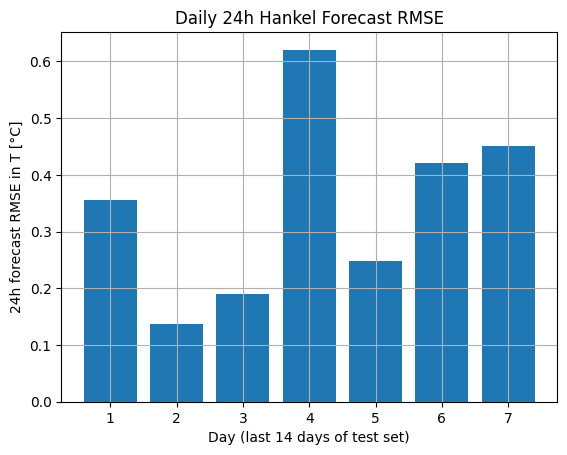

In [144]:
steps_per_day = N  # assuming N = 24 = 24 hours
num_days = 7

T_test = len(Y_test)

# Choose the start of the 14-day evaluation window in the *test* set
t0_first = T_test - num_days * steps_per_day

if t0_first - T_ini < 0:
    raise ValueError(
        "Not enough past data in test set for 14-day Hankel analysis. "
        "Reduce num_days or T_ini.")
X_adapt, Y_adapt = X[:T_train + t0_first], Y[:T_train + t0_first]
U_H_adapt, m = hankel_matrix(X_adapt, L)
Y_H_adapt, p = hankel_matrix(Y_adapt, L)

U_H_adapt_p = U_H_adapt[:T_ini * m, :]
U_H_adapt_f = U_H_adapt[T_ini * m:, :]
Y_H_adapt_p = Y_H_adapt[:T_ini * p, :]
Y_H_adapt_f = Y_H_adapt[T_ini * p:, :]

rmse_y_days = []  # RMSE per day on dT/dt
rmse_T_days = []  # RMSE per day on indoor temperature

# Store per-step temperature errors (shape: num_days x (steps_per_day+1))
temp_err_all = np.zeros((num_days, steps_per_day + 1))
T_true_all = np.zeros((num_days, steps_per_day + 1))
T_pred_all = np.zeros((num_days, steps_per_day + 1))

for d in range(num_days):
    # Index in Y_test where this day's 24h prediction starts
    t0_te = t0_first + d * steps_per_day  # index into Y_test

    # Redefine hankel to to have latest data
    X_adapt, Y_adapt = X[:T_train + t0_te], Y[:T_train + t0_te]
    U_H_adapt, m = hankel_matrix(X_adapt, L)
    Y_H_adapt, p = hankel_matrix(Y_adapt, L)

    U_H_adapt_p = U_H_adapt[:T_ini * m, :]
    U_H_adapt_f = U_H_adapt[T_ini * m:, :]
    Y_H_adapt_p = Y_H_adapt[:T_ini * p, :]
    Y_H_adapt_f = Y_H_adapt[T_ini * p:, :]

    H_tr_adapt = np.vstack([U_H_adapt_p, Y_H_adapt_p, U_H_adapt_f])

    # Corresponding Hankel column index in U_H_te / Y_H_te
    # Column j uses data Y_test[j : j + L], so the future starts at j + T_ini.
    # We want future to start at t0_te -> j = t0_te - T_ini
    k_col = t0_te - T_ini

    # Sanity check: ensure this column is valid
    if k_col < 0 or k_col >= U_H_te.shape[1]:
        raise IndexError(f"Invalid Hankel column index {k_col} for day {d}.")

    # Extract past/future blocks for this specific day from the *test* Hankel
    u_p_te_d = U_H_te[:T_ini * m, [k_col]]
    y_p_te_d = Y_H_te[:T_ini * p, [k_col]]
    u_f_te_d = U_H_te[T_ini * m:, [k_col]]
    y_f_te_d = Y_H_te[T_ini * p:, [k_col]]  # ground-truth dT/dt over horizon

    # Right-hand side for this day's trajectory
    rhs_d = np.vstack([u_p_te_d, y_p_te_d, u_f_te_d]).ravel()

    # Solve for g_d using noise with lam
    #g_d = np.linalg.solve(
    #    H_tr_adapt.T @ H_tr_adapt + lam * np.eye(H_tr_adapt.shape[1]),
    #    H_tr_adapt.T @ rhs_d
    #)
    # noise free:
    g_d, *_ = np.linalg.lstsq(H_tr_adapt, rhs_d, rcond=None)
    # Predict future dT/dt using training Y_f_tr and the new g_d
    y_diff_pred_d = (Y_H_adapt_f @ g_d).reshape(N, p)
    y_diff_true_d = y_f_te_d.reshape(N, p)

    # RMSE on dT/dt for this day (scalar, since p=1)
    rmse_y = np.sqrt(np.mean((y_diff_pred_d - y_diff_true_d) ** 2))
    rmse_y_days.append(rmse_y)

    # --- Reconstruct indoor temperature trajectories for interpretability ---
    # Map index t0_te in Y_test back to global index in Y (and T_in)
    # Recall: Y_test = Y[T_train - (L-1):]
    t0_global = (T_train - (L - 1)) + t0_te

    # Starting indoor temperature at the forecast start
    T0 = T_in[t0_global]

    # True indoor temperatures for this day: length steps_per_day+1
    T_true_d = T_in[t0_global: t0_global + steps_per_day + 1]

    if len(T_true_d) < steps_per_day + 1:
        raise ValueError(
            f"Not enough T_in samples to build true 24h trajectory for day {d}.")

    # Forward Euler reconstruction from predicted dT/dt
    T_pred_d = np.empty_like(T_true_d)
    T_pred_d[0] = T0
    for k_step in range(steps_per_day):
        # Y = dT/dt, so ΔT = dt_train * Y
        T_pred_d[k_step + 1] = T_pred_d[k_step] + dt_train * y_diff_pred_d[
            k_step, 0]

        # Save trajectories for plotting later
    T_true_all[d, :] = T_true_d
    T_pred_all[d, :] = T_pred_d
    # RMSE on temperature for this day
    rmse_T = np.sqrt(np.mean((T_pred_d - T_true_d) ** 2))
    rmse_T_days.append(rmse_T)

    # Store error trajectory (predicted minus true)
    temp_err_all[d, :] = T_pred_d - T_true_d

rmse_y_days = np.array(rmse_y_days)
rmse_T_days = np.array(rmse_T_days)

print("=== 14-Day Daily Hankel Forecast Analysis ===")
print(
    f"Mean RMSE on dT/dt over 14 days: {rmse_y_days.mean():.4f} [°C/time-unit]")
print(f"Mean RMSE on T over 14 days:    {rmse_T_days.mean():.4f} [°C]")
print("Per-day RMSE on T [°C]:")
for d, val in enumerate(rmse_T_days):
    print(f"  Day {d + 1:2d}: {val:.4f}")

t_hours = np.arange(steps_per_day + 1)  # interpret as hours ahead if dt_train=1

plt.figure()
plt.bar(np.arange(1, num_days + 1), rmse_T_days)
plt.xlabel("Day (last 14 days of test set)")
plt.ylabel("24h forecast RMSE in T [°C]")
plt.title("Daily 24h Hankel Forecast RMSE")
plt.grid(True)

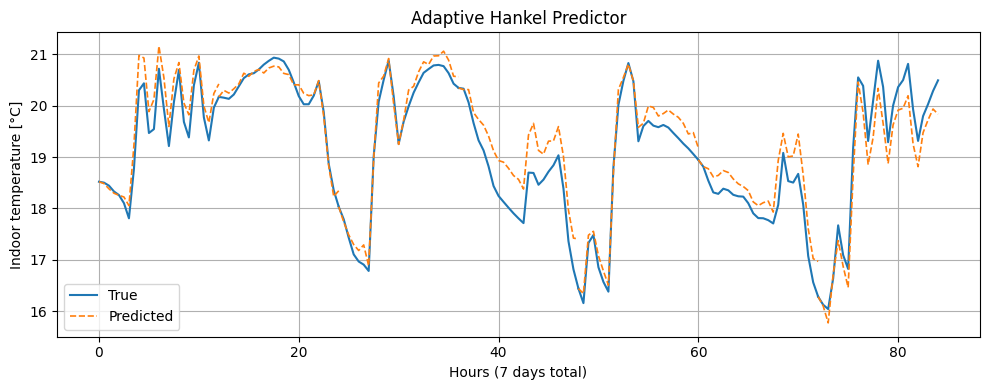

In [145]:
# === Continuous 14-day plot of predicted vs true indoor temperature ===
t_hours_day = np.arange(steps_per_day + 1)  # local (0–24 h)
t_hours_full = np.arange(
    (steps_per_day + 1) * num_days) * dt_train  # total time span in hours

plt.figure(figsize=(10, 4))

for d in range(num_days):
    # compute time offset for this day in hours
    t_offset = d * steps_per_day * dt_train
    t_global = t_hours_day * dt_train + t_offset

    # plot true and predicted for this day in continuous time
    plt.plot(t_global, T_true_all[d, :], color="tab:blue", linewidth=1.5)
    plt.plot(t_global, T_pred_all[d, :], "--", color="tab:orange",
             linewidth=1.2)

# Labels and legend (only one legend entry)
plt.xlabel("Hours (7 days total)")
plt.ylabel("Indoor temperature [°C]")
plt.title("Adaptive Hankel Predictor")
plt.legend(["True", "Predicted"], loc="best")
plt.grid(True)
plt.tight_layout()
plt.savefig('online_hankel.png')
plt.show()

## Implementing control loop

In [146]:
setpoint = 23
t_step_ctr = int(timestep_control)
n_horizon = int(12/(timestep_control/60)) #  hours /time-step (h)
T_pref = 21 # Celsius
training_days = 0
rate_type = "flat" # or "tou" 

In [147]:
plan_cache = None        # holds last computed hourly plan
plan_valid_until = None  # timestamp when the current plan expires
#t_step_ctr = 3600.0      # [s] controller timestep (1 hour)
#n_horizon   = 24         # 24 hours

In [148]:
# --- Set up dwelling and time grid ---
start_time = dt.datetime(2018, 2, 1 + training_days, 0, 0)

dwelling_args.update({
    "start_time": start_time,
    "duration": dt.timedelta(days=14),
    "initialization_time": dt.timedelta(days=1),
    "verbosity": 9
    }
)

dwelling = Dwelling(**dwelling_args)
sim_times = dwelling.sim_times  

# Disable internal iterator so we MUST pass schedule_inputs each minute
dwelling.schedule = pd.DataFrame()
dwelling.schedule_iterable = iter([])  

hvac = dwelling.get_equipment_by_end_use("HVAC Heating")
hvac.temp_deadband = HP_deadband
hvac.er_setpoint_offset = ER_lowerbound
er = hvac.er_capacity_rated/1000

# storage for logging the simulation
log = []

# storage for logging each trajectory
hist = []

# optional: initial control
current_setpoint = 21.0  # °C

2025-12-16 08:31:21.748110 - ochre at 2018-02-01 00:00:00: Initializing ochre (OCHRE v0.9.1)
2025-12-16 08:31:21.748406 - ochre at 2018-02-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre.csv
2025-12-16 08:31:21.751714 - ochre at 2018-02-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_metrics.csv
2025-12-16 08:31:21.751825 - ochre at 2018-02-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_hourly.csv
2025-12-16 08:31:21.751940 - ochre at 2018-02-01 00:00:00: Removing previous results file: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_schedule.csv
2025-12-16 08:31:23.157481 - ochre at 2018-02-01 00:00:00: Saved schedule to: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_schedule.csv
2025-12-16 08:31:23.36

In [149]:
Q_hp_W = hvac.capacity_ideal          # 9186.02 W
EIR_hp = hvac.eir_list[-1]            # 0.37088...
P_hp_W = Q_hp_W * EIR_hp
P_fan_W = heater.fan_power_max          # 342.825 W

P_hp_kW  = P_hp_W / 1000
P_fan_kW = P_fan_W / 1000
P_hp_max = P_hp_kW + P_fan_kW# + er

In [150]:
j = 0
sim_start = timestep_sim*60*37
deepc = True

In [151]:
# record data
T_in_hist = []
T_out_hist = []
q_hp_hist = []
q_solar_hist = []

In [152]:
#Steps
## build hankel over historical data
## initialize last 24 hours of data each time-step

In [153]:
for t in sim_times:
    j = j+1 

    # Build control_signal for this time step ---
    contr_signal = {
        "HVAC Heating": {
            # keys defined in HVAC.update_external_control
            "Setpoint": current_setpoint,     # °C
            #"Deadband": current_deadband,     # °C
            # you could also use "Load Fraction", "Max Capacity Fraction", etc.
        }
    }
    
    
    # Re-optimize once per hour (at the top of the hour)
    if (t.minute == 0 or t.minute == 30) and j >= sim_start and deepc == True:
        #print('MPC start')
        df_hist = pd.DataFrame(log).set_index("Time") if log else pd.DataFrame(index=[t])
        
        T_out_hist = (df_hist["Temperature - Outdoor (C)"].resample(f'{timestep_control}min').mean()
                    .to_numpy())
        q_hp_hist = (df_hist["HVAC Heating Delivered (W)"].resample(f'{timestep_control}min').mean()
             .to_numpy()/1000)
        T_in_hist = df_hist["Temperature - Indoor (C)"].resample(f'{timestep_control}min').mean()

        df_T_in = T_in_hist.to_frame()
        df_weather_sim = attach_epw_to_df(df_T_in, 
                                         dwelling_args["weather_file"])
        df_weather_sim_1hr  = df_weather_sim.resample(f'{timestep_control}min').mean()
        q_solar_hist = df_weather_sim_1hr[("Global Horizontal Irradiance "
                                           "(W/m^2) [EPW]")].to_numpy()/1000
        
        
        # forecast weather for the next 24 hours (hourly samples)
        df_pred = weather_predict(dwelling_args["weather_file"], t_now=t, n_horizon=n_horizon)  # returns hourly index
        T_out_hat = df_pred["Dry Bulb (C)"].to_numpy()  # shape (N,)
        q_solar_hat = (df_pred["Global Horizontal Radiation (Wh/m^2)"]
                       .to_numpy()/1000)
        
        # comfort schedule, compute min/max across those arrays instead:
        T_min, T_max = comfort_schedule(t, n_horizon= int(n_horizon), 
                       time_step = timestep_control)

        # COP forecast (vector, hourly)
        eta_hat = forecast_COP_vector(T_out_hat, hvac)  # shape (N,)
        #print(t)
        #print(T0)
        
        # Solve MPC (hourly)
        sol = run_DeePC(
            U_p_tr = U_p_tr,
            Y_p_tr = Y_p_tr,
            U_f_tr = U_f_tr,
            Y_f_tr = Y_f_tr,
            T_out_hat=T_out_hat,
            q_solar_hat = q_solar_hat,
            eta_hat=eta_hat,
            T_in_hist = T_in_hist,
            T_out_hist = T_out_hist,
            q_hp_hist = q_hp_hist,
            q_solar_hist = q_solar_hist,
            T_ini = T_ini,
            N=n_horizon,
            dt=t_step_ctr,  # seconds
            T_min=T_min,
            T_max=T_max,
            T_pref = T_pref*np.ones_like(T_min),
            P_r = er,
            HP_deadband = HP_deadband,
            P_max = P_hp_max
        )
        # If T_min/T_max are vectors (Series/ndarray), grab hour-0; if scalars, use as-is
        lo0 = T_min.iloc[0] if hasattr(T_min, "iloc") else (T_min[0] if np.ndim(T_min) else T_min)
        hi0 = T_max.iloc[0] if hasattr(T_max, "iloc") else (T_max[0] if np.ndim(T_max) else T_max)
        
        if sol["P_hp"][0] > 1:
            setpoint_adjust = sol["T_in"][1] + HP_deadband
        else: 
            setpoint_adjust = sol["T_in"][1]
        setpoint_1hr = float(np.clip(setpoint_adjust, lo0, hi0))
        #print("T_sp:",sol["T_in"][1])
        #print("q_hp:",sol["q_hp"][0])
        #print("P_hp:",sol["P_hp"][0])

        # Cache results for this hour
        plan_cache = {
            "T_traj": sol["T_in"],         # (N,)
            "P_traj": sol["P_hp"],         # (N,)
            "q_traj": sol["q_hp"],         # (N,)
            "Cost_p_traj": sol["Cost_p"],
            "Cost_db_traj": sol["Cost_db"],
            "Cost_er_traj": sol["Cost_er"],
            "Cost_pref_traj": sol["Cost_pref"],
            "setpoint_1hr_adjust":  setpoint_adjust,
            "setpoint_1hr_sent": setpoint_1hr,
            "Time":t,
        }
        hist.append(plan_cache)
        current_setpoint = setpoint_1hr
        plan_valid_until = t.floor('h') + pd.Timedelta(hours=1)
        last_mpc_time = t.floor('h')

    # Build schedule_inputs for THIS minute (Option A core)
    s = {
        "HVAC Heating Setpoint (C)": current_setpoint,
        #"HVAC Heating Deadband (C)": current_deadband,
    }

    # Advance simulation one minute
    status = dwelling.update(control_signal=contr_signal, schedule_inputs=s)
    status["Time"] = t
    status["HVAC Setpoint (C)"] = current_setpoint
    log.append(status)
    

# --- Finalize & postprocess ---
dwelling.finalize()
df_ctr = pd.DataFrame(log).set_index("Time")        

Set parameter Username
Academic license - for non-commercial use only - expires 2026-06-05


/Users/levipremer/PycharmProjects/OCHRE_test/.venv/lib/python3.12/site-packages/cvxpy/atoms/affine/reshape.py:68: FutureWarning: 
    You didn't specify the order of the reshape expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  warnings.warn(reshape_order_warning, FutureWarning)
/Users/levipremer/PycharmProjects/OCHRE_test/.venv/lib/python3.12/site-packages/cvxpy/atoms/affine/reshape.py:68: FutureWarning: 
    You didn't specify the order of the reshape expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  warnings.warn(reshape_order_warning, FutureWarning)
/Users/levipremer/PycharmProjects/OCHRE_test/.venv/lib/p

2025-12-16 08:40:16.423273 - ochre at 2018-02-15 00:00:00: Simulation complete, time series results saved to: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre.csv
2025-12-16 08:40:16.425028 - ochre at 2018-02-15 00:00:00: Post-processing metrics saved to: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_metrics.csv
2025-12-16 08:40:16.507364 - ochre at 2018-02-15 00:00:00: Hourly results saved to: /Users/levipremer/PycharmProjects/OCHRE_test/ochre/defaults/Input Files/ochre_hourly.csv


In [154]:
days_eval = 7*24*60
pref_hours = list(range(18, 24)) + list(range(0, 9))  # 6pm–midnight and 0–9am

df_mpc = df_ctr[df_ctr["TimeIndex"] >= sim_start] if "TimeIndex" in df_ctr else df_ctr.iloc[sim_start:].copy()
df_mpc = df_mpc.iloc[:days_eval].copy()
# Ensure datetime index is present
df_mpc.index = pd.to_datetime(df_mpc.index)

# --- 2. Filter for preference hours (6 PM → 9 AM) ---
df_pref = df_mpc[df_mpc.index.hour.isin(pref_hours)]

# --- 3. Extract temperature error ---
T_in = df_pref["Temperature - Indoor (C)"].values
err = T_in - T_pref

# RMSE
rmse = np.sqrt(np.mean(err**2))

# --- 4. Compute energy usage (kWh) ---
# Assuming 1–minute resolution and HVAC heating power column:
power_col_candidates = ['HVAC Heating Electric Power (kW)']

if not power_col_candidates:
    raise KeyError("Could not find HVAC kW power column in df_ctr. Tell me your column name.")

P_kW = df_mpc[power_col_candidates[0]]

# 1 minute = 1/60 hour
dt_hours = 1.0/60.0
energy_kWh_ts = P_kW * dt_hours         # per-timestep energy [kWh]
energy_kWh = energy_kWh_ts.sum()        # total energy [kWh]

# --- 4b. Use electricity_price() to compute cost (flat + TOU) ---
t_now = df_mpc.index[0]                 # start of MPC horizon / eval period
timestep_min = 1.0                      # 1-minute simulation timestep
N = len(df_mpc)                         # number of timesteps

# Price vectors [$ / kWh] over the horizon
c_flat = electricity_price(t_now, timestep_min, N, rate_type="flat")
c_tou  = electricity_price(t_now, timestep_min, N, rate_type="tou")

# Make sure they are NumPy arrays
c_flat = np.asarray(c_flat, dtype=float)
c_tou  = np.asarray(c_tou, dtype=float)

# Cost = sum_t (energy_t [kWh] * price_t [$ / kWh])
cost_flat = np.dot(energy_kWh_ts, c_flat)
cost_tou  = np.dot(energy_kWh_ts, c_tou)


# --- 5. Print results ---
print("=== DeePC Performance ===")
print(f"Preference temperature: {T_pref:.2f} °C (21 °F)")
print(f"Temperature Pref RMSE during occupancy:       {rmse:.3f} °C")
print(f"Energy usage:           {energy_kWh:.2f} kWh")
print(f"Number of minutes:      {len(df_mpc)}")

print("\n=== Cost of Operation ===")
print(f"Flat rate (0.093 $/kWh):                ${cost_flat:.2f}")
print(f"TOU rate (0.21 peak 17–21 h, else 0.07): ${cost_tou:.2f}")

=== DeePC Performance ===
Preference temperature: 21.00 °C (21 °F)
Temperature Pref RMSE during occupancy:       2.865 °C
Energy usage:           312.76 kWh
Number of minutes:      10080

=== Cost of Operation ===
Flat rate (0.093 $/kWh):                $29.09
TOU rate (0.21 peak 17–21 h, else 0.07): $31.22


In [155]:
pref_hours = list(range(18, 24)) + list(range(0, 9))  # 6pm–midnight and 0–9am

df_mpc = df_ctr[df_ctr["TimeIndex"] >= sim_start] if "TimeIndex" in df_ctr else df_ctr.iloc[sim_start:].copy()

# Ensure datetime index is present
df_mpc.index = pd.to_datetime(df_mpc.index)

# --- 2. Filter for preference hours (6 PM → 9 AM) ---
df_pref = df_mpc[df_mpc.index.hour.isin(pref_hours)]

# --- 3. Extract temperature error ---
T_in = df_pref["Temperature - Indoor (C)"].values
err = T_in - T_pref

# RMSE
rmse = np.sqrt(np.mean(err**2))

# --- 4. Compute energy usage (kWh) ---
# Assuming 1–minute resolution and HVAC heating power column:
power_col_candidates = ['HVAC Heating Electric Power (kW)']

if not power_col_candidates:
    raise KeyError("Could not find HVAC kW power column in df_ctr. Tell me your column name.")

P_kW = df_mpc[power_col_candidates[0]]

# 1 minute = 1/60 hour
energy_kWh = (P_kW * (1/60)).sum()

# --- 5. Print results ---
print("=== MPC Performance ===")
print(f"Preference temperature: {T_pref:.2f} °C (21 °F)")
print(f"Temperature Pref RMSE during occupancy:       {rmse:.3f} °C")
print(f"Energy usage:           {energy_kWh:.2f} kWh")
print(f"Number of minutes:      {len(df_mpc)}")

=== MPC Performance ===
Preference temperature: 21.00 °C (21 °F)
Temperature Pref RMSE during occupancy:       2.758 °C
Energy usage:           474.62 kWh
Number of minutes:      17940


<Axes: xlabel='Time'>

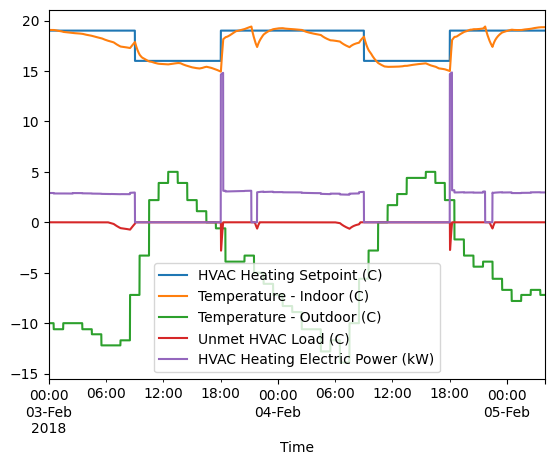

In [156]:
cols_to_plot = [
    "HVAC Heating Setpoint (C)",
    "Temperature - Indoor (C)",
    "Temperature - Outdoor (C)",
    "Unmet HVAC Load (C)",
    "HVAC Heating Electric Power (kW)",
]
df_ctr.loc[:, cols_to_plot][48*60:100*60].plot()

In [157]:
df_ctr

,Total Electric Power (kW),Total Reactive Power (kVAR),Total Gas Power (therms/hour),Total Electric Energy (kWh),Total Reactive Energy (kVARh),Total Gas Energy (therms),HVAC Cooling Electric Power (kW),HVAC Heating Electric Power (kW),Water Heating Electric Power (kW),Other Electric Power (kW),...,Attic Wall Attic LWR Gain (W),Attic Wall Attic Surface Temperature (C),Attic Wall Attic Film Coefficient (m^2-K/W),Attic Roof Attic LWR Gain (W),Attic Roof Attic Surface Temperature (C),Attic Roof Attic Film Coefficient (m^2-K/W),Attic Floor Attic LWR Gain (W),Attic Floor Attic Surface Temperature (C),Attic Floor Attic Film Coefficient (m^2-K/W),HVAC Setpoint (C)
Time,,,,,,,,,,,,,,,,,,,,,
2018-02-01 00:00:00,3.398673,2.190681,0.0,0.056645,0.036511,0.0,0.05,3.100762,0.001,0.230603,...,-13.316635,-9.562181,0.325486,216.917414,-10.269587,0.536264,-203.600779,-9.256878,0.561134,21.0
2018-02-01 00:01:00,3.399522,2.191229,0.0,0.056659,0.036520,0.0,0.05,3.101611,0.001,0.230603,...,-12.945621,-9.565427,0.325486,217.670875,-10.268701,0.536264,-204.725253,-9.251452,0.561134,21.0
2018-02-01 00:02:00,3.400337,2.191756,0.0,0.056672,0.036529,0.0,0.05,3.102426,0.001,0.230603,...,-12.472556,-9.566018,0.325486,218.413749,-10.263494,0.536264,-205.941193,-9.241548,0.561134,21.0
2018-02-01 00:03:00,3.401123,2.192263,0.0,0.056685,0.036538,0.0,0.05,3.103212,0.001,0.230603,...,-11.768211,-9.559020,0.325486,218.426615,-10.245288,0.536264,-206.658404,-9.221715,0.561134,21.0
2018-02-01 00:04:00,3.401883,2.192755,0.0,0.056698,0.036546,0.0,0.05,3.103972,0.001,0.230603,...,-11.242028,-9.549625,0.325486,218.160737,-10.226857,0.536264,-206.918709,-9.203444,0.561134,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-02-14 23:55:00,3.426482,2.207568,0.0,0.057108,0.036793,0.0,0.05,3.125891,0.001,0.231478,...,-26.146620,-0.248464,0.325486,190.525203,-1.014385,0.536264,-164.378583,-0.244473,0.561134,19.0
2018-02-14 23:56:00,3.428654,2.208971,0.0,0.057144,0.036816,0.0,0.05,3.128063,0.001,0.231478,...,-25.918786,-0.256830,0.325486,190.769741,-1.020068,0.536264,-164.850955,-0.248528,0.561134,19.0
2018-02-14 23:57:00,3.430784,2.210347,0.0,0.057180,0.036839,0.0,0.05,3.130192,0.001,0.231478,...,-25.693897,-0.264966,0.325486,191.007602,-1.025546,0.536264,-165.313705,-0.252415,0.561134,19.0


2018-02-03 13:00:00
3.8999999999639146
16.0


ValueError: x and y must have same first dimension, but have shapes (24,) and (25,)

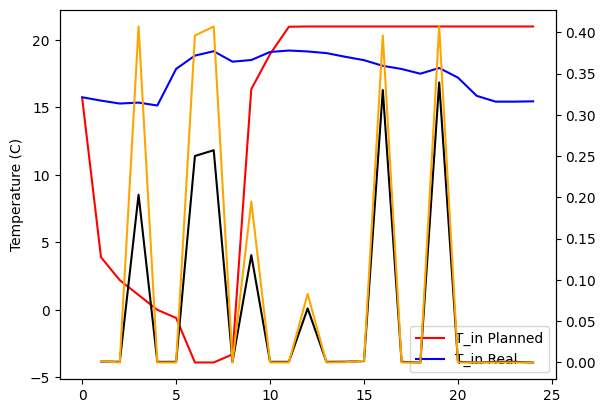

In [158]:
dic_traj = hist[48]
t_pull = pd.Timestamp(dic_traj["Time"])
n_pull = len(dic_traj["P_traj"])
col_list = ["HVAC Heating Setpoint (C)",
            "Temperature - Indoor (C)",
            "HVAC Heating Electric Power (kW)",
            "HVAC Heating Delivered (W)"]
df_segment = df_ctr[col_list].loc[t_pull: t_pull + pd.Timedelta(hours=n_pull)]
df_segment = df_segment.resample('h').mean()

print(dic_traj["Time"])
print(dic_traj["setpoint_1hr_adjust"])
print(dic_traj["setpoint_1hr_sent"])

fig, ax1 = plt.subplots()
ax1.plot(dic_traj["T_traj"], color = 'red',  label = "T_in Planned")
ax1.plot(df_segment["Temperature - Indoor (C)"].to_numpy(), color = 'blue',
                                                label = "T_in Real")
ax1.set_ylabel("Temperature (C)")
ax1.legend()

ax2 = ax1.twinx()

ax2.plot(np.arange(1,25), dic_traj["P_traj"], color = "black", label = "P "
                                                                       "Planned") 
ax2.plot(np.arange(1,25), dic_traj["q_traj"], color = "orange", label = ("Q "
                                                                      "Planned"))
ax2.plot(np.arange(1,25), df_segment[col_list[3]].to_numpy()/1000, color = 
                                                "purple", label = "P real")
ax2.set_ylabel("Energy (kW)")
ax2.legend()

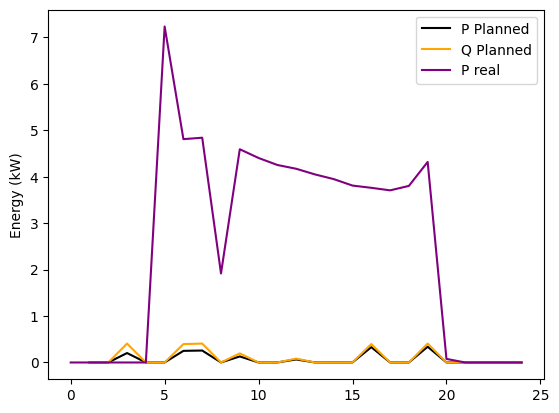

In [159]:
fig, ax2 = plt.subplots()

ax2.plot(np.arange(1,25), dic_traj["P_traj"], color = "black", label = "P "
                                                                       "Planned") 
ax2.plot(np.arange(1,25), dic_traj["q_traj"], color = "orange", label = ("Q "
                                                                      "Planned"))
ax2.plot(np.arange(0,25), df_segment[col_list[3]].to_numpy()/1000, color = 
                                                "purple", label = "P real")
ax2.set_ylabel("Energy (kW)")
ax2.legend()

In [234]:
df_ctr

,Total Electric Power (kW),Total Reactive Power (kVAR),Total Gas Power (therms/hour),Total Electric Energy (kWh),Total Reactive Energy (kVARh),Total Gas Energy (therms),Water Heating Electric Power (kW),HVAC Cooling Electric Power (kW),Other Electric Power (kW),HVAC Heating Electric Power (kW),...,Attic Wall Attic LWR Gain (W),Attic Wall Attic Surface Temperature (C),Attic Wall Attic Film Coefficient (m^2-K/W),Attic Roof Attic LWR Gain (W),Attic Roof Attic Surface Temperature (C),Attic Roof Attic Film Coefficient (m^2-K/W),Attic Floor Attic LWR Gain (W),Attic Floor Attic Surface Temperature (C),Attic Floor Attic Film Coefficient (m^2-K/W),HVAC Setpoint (C)
Time,,,,,,,,,,,,,,,,,,,,,
2018-02-01 00:00:00,3.398673,2.190681,0.0,0.056645,0.036511,0.0,0.001,0.05,0.230603,3.100762,...,-13.316635,-9.562181,0.325486,216.917414,-10.269587,0.536264,-203.600779,-9.256878,0.561134,21.0
2018-02-01 00:01:00,3.399522,2.191229,0.0,0.056659,0.036520,0.0,0.001,0.05,0.230603,3.101611,...,-12.945621,-9.565427,0.325486,217.670875,-10.268701,0.536264,-204.725253,-9.251452,0.561134,21.0
2018-02-01 00:02:00,3.400337,2.191756,0.0,0.056672,0.036529,0.0,0.001,0.05,0.230603,3.102426,...,-12.472556,-9.566018,0.325486,218.413749,-10.263494,0.536264,-205.941193,-9.241548,0.561134,21.0
2018-02-01 00:03:00,3.401123,2.192263,0.0,0.056685,0.036538,0.0,0.001,0.05,0.230603,3.103212,...,-11.768211,-9.559020,0.325486,218.426615,-10.245288,0.536264,-206.658404,-9.221715,0.561134,21.0
2018-02-01 00:04:00,3.401883,2.192755,0.0,0.056698,0.036546,0.0,0.001,0.05,0.230603,3.103972,...,-11.242028,-9.549625,0.325486,218.160737,-10.226857,0.536264,-206.918709,-9.203444,0.561134,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-02-14 23:55:00,0.300591,0.188442,0.0,0.005010,0.003141,0.0,0.001,0.05,0.231478,0.000000,...,-25.288084,-0.199181,0.325486,196.124007,-0.964003,0.536264,-170.835923,-0.168294,0.561134,21.0
2018-02-14 23:56:00,0.300591,0.188442,0.0,0.005010,0.003141,0.0,0.001,0.05,0.231478,0.000000,...,-25.132173,-0.208997,0.325486,195.864685,-0.971134,0.536264,-170.732512,-0.176131,0.561134,21.0
2018-02-14 23:57:00,0.300591,0.188442,0.0,0.005010,0.003141,0.0,0.001,0.05,0.231478,0.000000,...,-24.878076,-0.225614,0.325486,195.899825,-0.984328,0.536264,-171.021749,-0.188478,0.561134,21.0


In [235]:
heater = dwelling.get_equipment_by_end_use("HVAC Heating")
heater.temp_deadband
heater.deadband_offset
heater.er_setpoint_offset
heater.hp_lockout_temp
heater.er_lockout_temp
heater.er_hard_lockout_time
heater.er_soft_lockout_time


datetime.timedelta(0)

In [236]:
db   = heater.temp_deadband
off  = heater.deadband_offset
er_o = heater.er_setpoint_offset
hvac_mult = heater.hvac_mult  # +1 for heating

# HP on-threshold (from run_thermostat_control)
T_hp_on  = df["HVAC Heating Setpoint (C)"] - hvac_mult * db * (1 - off)

# ER on-threshold (from run_er_thermostat_control)
T_er_on  = df["HVAC Heating Setpoint (C)"] - er_o


NameError: name 'df' is not defined

In [237]:
heater.er_setpoint_offset

3

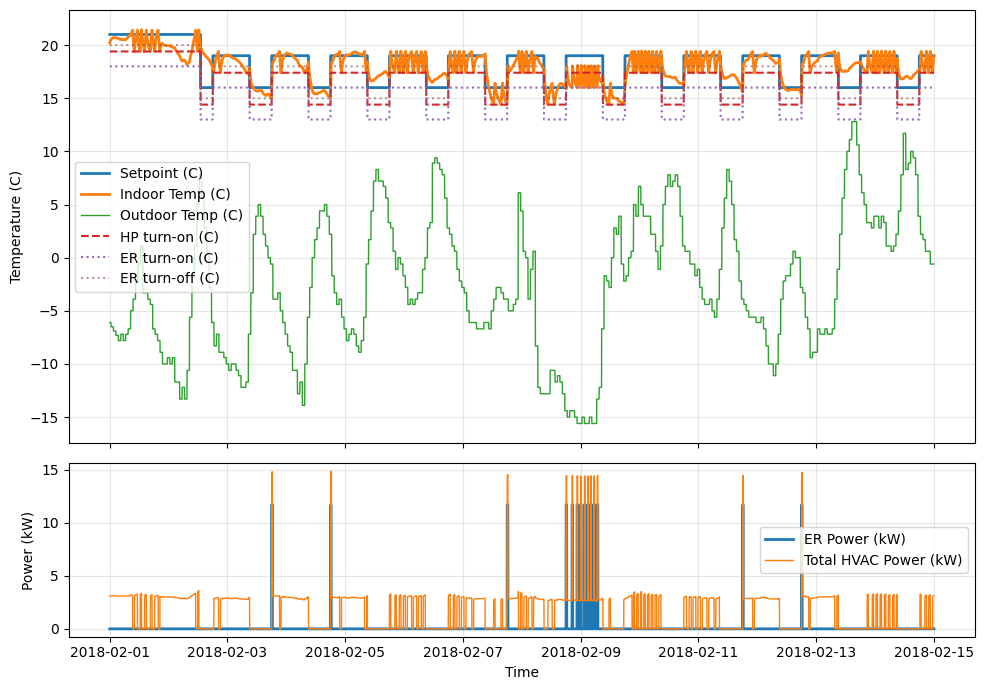

In [160]:
# --- Slice time window if requested ---
t_start = df_ctr.index[0]
t_end = df_ctr.index[-1]

# Column names from OCHRE Outputs.rst
T_set = df_ctr["HVAC Heating Setpoint (C)"]
T_in  = df_ctr["Temperature - Indoor (C)"]

# Optional series – only plot if they exist
T_out = df_ctr.get("Temperature - Outdoor (C)")
P_hp  = df_ctr.get("HVAC Heating Electric Power (kW)")        # total HP+ER
P_er  = df_ctr.get("HVAC Heating ER Power (kW)")              # ER only, if verbosity >= 7

# --- Reconstruct thermostat thresholds from HVAC.py ---

db   = heater.temp_deadband
off  = heater.deadband_offset
er_o = heater.er_setpoint_offset
hvac_mult = heater.hvac_mult   # +1 for heating

# HP thermostat (run_thermostat_control)
T_hp_on  = T_set - hvac_mult * db * (1 - off)
T_hp_off = T_set + hvac_mult * db * (off)

# ER thermostat (run_er_thermostat_control)
T_er_on  = T_set - er_o
T_er_off = T_er_on + db

# --- Plot ---

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [2.5, 1]}
)

# Temperatures & thresholds
ax1.plot(df_ctr.index, T_set,  label="Setpoint (C)",            linewidth=2)
ax1.plot(df_ctr.index, T_in,   label="Indoor Temp (C)",         linewidth=2)
if T_out is not None:
    ax1.plot(df_ctr.index, T_out, label="Outdoor Temp (C)",     linewidth=1)

ax1.plot(df_ctr.index, T_hp_on,  "--", label="HP turn-on (C)")
ax1.plot(df_ctr.index, T_er_on,  ":",  label="ER turn-on (C)")
ax1.plot(df_ctr.index, T_er_off, ":",  label="ER turn-off (C)", alpha=0.6)

ax1.set_ylabel("Temperature (C)")
ax1.legend(loc="best")
ax1.grid(True, alpha=0.3)

# Power – HP/ER
if P_er is not None:
    ax2.plot(df_ctr.index, P_er, label="ER Power (kW)", linewidth=2)
if P_hp is not None:
    ax2.plot(df_ctr.index, P_hp, label="Total HVAC Power (kW)", linewidth=1)

ax2.set_ylabel("Power (kW)")
ax2.set_xlabel(df_ctr.index.name or "Time")
ax2.legend(loc="best")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [239]:
# --- Slice time window if requested ---
days_in = 2
days_look = 1
#t_start = df_ctr.index[days_in*24*60]
#t_end = df_ctr.index[days_in*24*60 + days_look*24*60]
t_start = days_in*24*60
t_end = days_in*24*60 + days_look*24*60

# Column names from OCHRE Outputs.rst
T_set = df_ctr["HVAC Heating Setpoint (C)"]
T_in  = df_ctr["Temperature - Indoor (C)"]

# Optional series – only plot if they exist
T_out = df_ctr.get("Temperature - Outdoor (C)")
P_hp  = df_ctr.get("HVAC Heating Electric Power (kW)")        # total HP+ER
P_er  = df_ctr.get("HVAC Heating ER Power (kW)")              # ER only, if verbosity >= 7

T_min, T_max = comfort_schedule(df_ctr.index[days_in*24*60], 
                                n_horizon=days_look*24*60, time_step = 1)


In [240]:
len(T_in[t_start:t_end])

1440

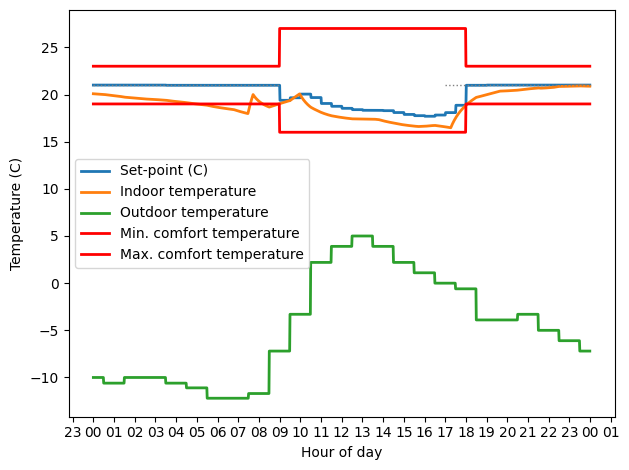

In [241]:
plt.plot(df_ctr.index[t_start:t_end], T_set[t_start:t_end], 
         label="Set-point (C)", linewidth=2)
plt.plot(df_ctr.index[t_start:t_end], T_in[t_start:t_end], 
         label="Indoor temperature", linewidth=2)
plt.plot(df_ctr.index[t_start:t_end], T_out[t_start:t_end], 
         label="Outdoor temperature", linewidth=2)
plt.plot(df_ctr.index[t_start:t_end], T_min, label="Min. comfort temperature",
         linewidth=2, color='red')
plt.plot(df_ctr.index[t_start:t_end], T_max, label="Max. comfort temperature",
         linewidth=2, color='red')

#-- add preference temp --
idx = df_ctr.index[t_start:t_end]
hours = idx.hour

# True where you want to show T_pref (outside 9–16)
mask = (hours < 9) | (hours > 16)

# Find contiguous segments of True in mask and plot them
in_segment = False
start = 0

for i in range(len(idx)):
    if mask[i] and not in_segment:
        # start of a new "outside 9–16" segment
        start = i
        in_segment = True
    elif (not mask[i] and in_segment):
        # end of segment at i-1
        end = i
        plt.plot(
            idx[start:end],
            [T_pref] * (end - start),
            linestyle=':',
            color='grey',
            linewidth=1,
        )
        in_segment = False

# If we ended while still in a segment, close it
if in_segment:
    end = len(idx)
    plt.plot(
        idx[start:end],
        [T_pref] * (end - start),
        linestyle=':',
        color='grey',
        linewidth=1,
    )

# --- X-axis formatting ---
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))

plt.ylabel("Temperature (C)")
plt.xlabel("Hour of day")
plt.tight_layout()
plt.legend(loc="best")
plt.show()

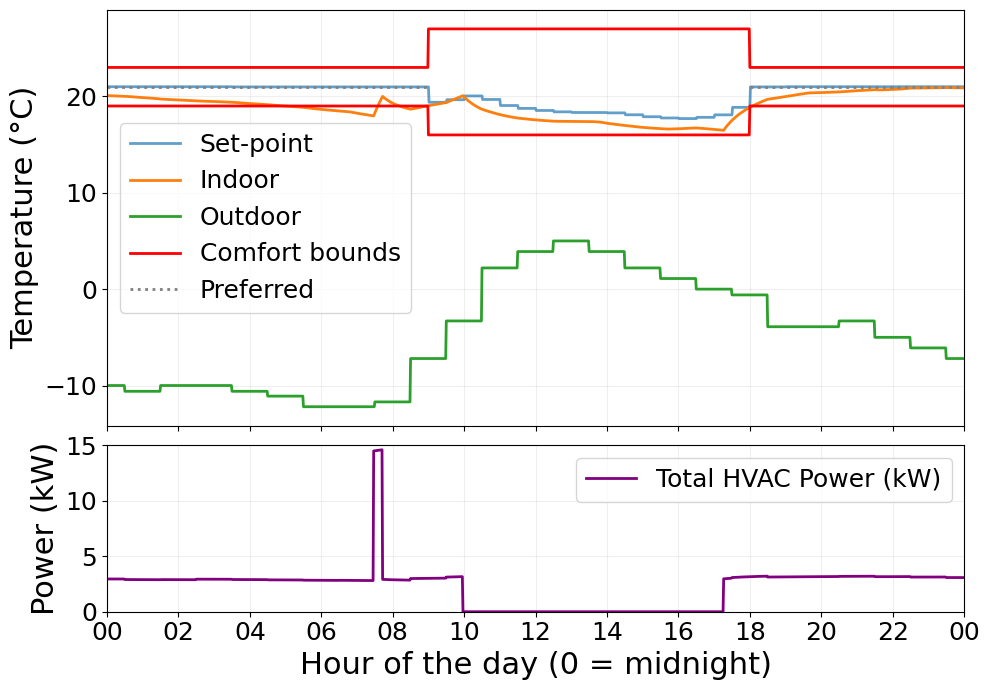

In [242]:
fs = 22

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [2.5, 1]}
)

# Temperatures & thresholds
ax1.plot(df_ctr.index[t_start:t_end], T_set[t_start:t_end], 
         label="Set-point", linewidth=2,alpha = 0.7)
ax1.plot(df_ctr.index[t_start:t_end], T_in[t_start:t_end], 
         label="Indoor", linewidth=2)
ax1.plot(df_ctr.index[t_start:t_end], T_out[t_start:t_end], 
         label="Outdoor", linewidth=2)
ax1.plot(df_ctr.index[t_start:t_end], T_min,
         linewidth=2, color='red', )
ax1.plot(df_ctr.index[t_start:t_end], T_max, label="Comfort bounds",
         linewidth=2, color='red')


#-- add preference temp --
idx = df_ctr.index[t_start:t_end]
hours = idx.hour

# True where you want to show T_pref (outside 9–16)
mask = (hours < 9) | (hours > 17)

# Find contiguous segments of True in mask and plot them
in_segment = False
start = 0
for i in range(len(idx)):
    if mask[i] and not in_segment:
        # start of a new "outside 9–16" segment
        start = i
        in_segment = True
    elif (not mask[i] and in_segment):
        # end of segment at i-1
        end = i
        ax1.plot(
            idx[start:end],
            [T_pref] * (end - start),
            linestyle=':',
            color='grey',
            linewidth=2,
        )
        in_segment = False

# If we ended while still in a segment, close it
if in_segment:
    end = len(idx)
    ax1.plot(
        idx[start:end],
        [T_pref] * (end - start),
        linestyle=':',
        color='grey',
        linewidth=2,
        label = 'Preferred'
    )

ax1.grid(True, alpha=0.2)   
ax1.legend(loc="best", fontsize = fs-4)
ax1.set_ylabel("Temperature (\u00b0C)", fontsize = fs)
ax1.tick_params(axis='y', which='major', labelsize = fs-4)
#ax1.set_xlabel("Hour of the day (0 = midnight)")

# Power – HP/ER
ax2.plot(df_ctr.index[t_start:t_end], P_hp[t_start:t_end], label=("Total HVAC "
                                                                 "Power (kW)"
                                                                  ""), 
         linewidth=2, color = 'purple')


ax2.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H'))

ax2.set_ylabel("Power (kW)", fontsize = fs)
ax2.set_xlabel("Hour of the day (0 = midnight)", fontsize = fs)
ax2.legend(loc="best", fontsize = fs-4)
ax2.grid(True, alpha=0.2)
ax2.tick_params(axis='x', which='major', labelsize = fs-4)
ax2.tick_params(axis='y', which='major', labelsize = fs-4)
ax2.set_ylim(0, 15)


# Force x-axis to run from midnight to midnight
day = idx[0].normalize()            # Midnight of that day
start_midnight = day                # 00:00
end_midnight   = day + pd.Timedelta(days=1)  # 24:00 next day

ax1.set_xlim(start_midnight, end_midnight)
ax2.set_xlim(start_midnight, end_midnight)


plt.tight_layout()
#plt.savefig("mpc_example.png", format="png", dpi=600)
plt.show()